## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../../data/raw/studentVle.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [2]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (10655280, 6)

Number of rows: 10655280
Number of columns: 6

Column names:
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [3]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


Last 5 rows:
         code_module code_presentation  id_student  id_site  date  sum_click
10655275         GGG             2014J      675811   896943   269          3
10655276         GGG             2014J      675578   896943   269          1
10655277         GGG             2014J      654064   896943   269          3
10655278         GGG             2014J      654064   896939   269          1
10655279         GGG             2014J      654064   896939   269          1


## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [4]:
print('Data types:')
print(df.dtypes)
print('\n' + '='*80 + '\n')
print('Data type summary:')
print(df.dtypes.value_counts())

Data types:
code_module            str
code_presentation      str
id_student           int64
id_site              int64
date                 int64
sum_click            int64
dtype: object


Data type summary:
int64    4
str      2
Name: count, dtype: int64


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [5]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

No missing values found in the dataset.


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [6]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 787170
Percentage of duplicates: 7.39%

Duplicate counts per column:
code_module: 10655273 duplicates (100.00%)
code_presentation: 10655276 duplicates (100.00%)
id_student: 10629206 duplicates (99.76%)
id_site: 10649012 duplicates (99.94%)
date: 10654985 duplicates (100.00%)
sum_click: 10654782 duplicates (100.00%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [7]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
         id_student       id_site          date     sum_click
count  1.065528e+07  1.065528e+07  1.065528e+07  1.065528e+07
mean   7.333336e+05  7.383234e+05  9.517400e+01  3.716946e+00
std    5.827060e+05  1.312196e+05  7.607130e+01  8.849047e+00
min    6.516000e+03  5.267210e+05 -2.500000e+01  1.000000e+00
25%    5.077430e+05  6.735190e+05  2.500000e+01  1.000000e+00
50%    5.882360e+05  7.300690e+05  8.600000e+01  2.000000e+00
75%    6.464840e+05  8.770300e+05  1.560000e+02  3.000000e+00
max    2.698588e+06  1.049562e+06  2.690000e+02  6.977000e+03


## 8. Overview of Categorical Columns

For categorical columns, we examine unique counts and sample values to understand categorical diversity.


In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f'{col}:')
        print(f'  Unique values: {df[col].nunique()}')
        print(f'  Sample values: {df[col].unique()[:5]}')
        print()
else:
    print('No categorical columns found in the dataset.')

code_module:


C:\Users\Dell\AppData\Local\Temp\ipykernel_23536\1950261300.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


  Unique values: 7
  Sample values: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE']
Length: 5, dtype: str

code_presentation:
  Unique values: 4
  Sample values: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str



## 9. Value Counts for Key Categorical or Target-like Columns

Detailed frequency analysis of categorical columns helps us identify class distributions and potential imbalances.


In [9]:
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(df[col].value_counts())
    print(f'\nPercentage distribution:')
    print(df[col].value_counts(normalize=True) * 100)
    print('\n' + '='*80 + '\n')

Value counts for code_module:
code_module
FFF    4014499
DDD    2166486
BBB    1567564
CCC    1207827
EEE     961433
GGG     387173
AAA     350298
Name: count, dtype: int64

Percentage distribution:
code_module
FFF    37.676147
DDD    20.332511
BBB    14.711617
CCC    11.335479
EEE     9.023066
GGG     3.633626
AAA     3.287553
Name: proportion, dtype: float64


Value counts for code_presentation:
code_presentation
2014J    3619452
2013J    2988784
2014B    2160176
2013B    1886868
Name: count, dtype: int64

Percentage distribution:
code_presentation
2014J    33.968624
2013J    28.049793
2014B    20.273292
2013B    17.708291
Name: proportion, dtype: float64




## 10. VLE Activity and Engagement Analysis

Analyze student engagement patterns and activity distribution across learning environments.


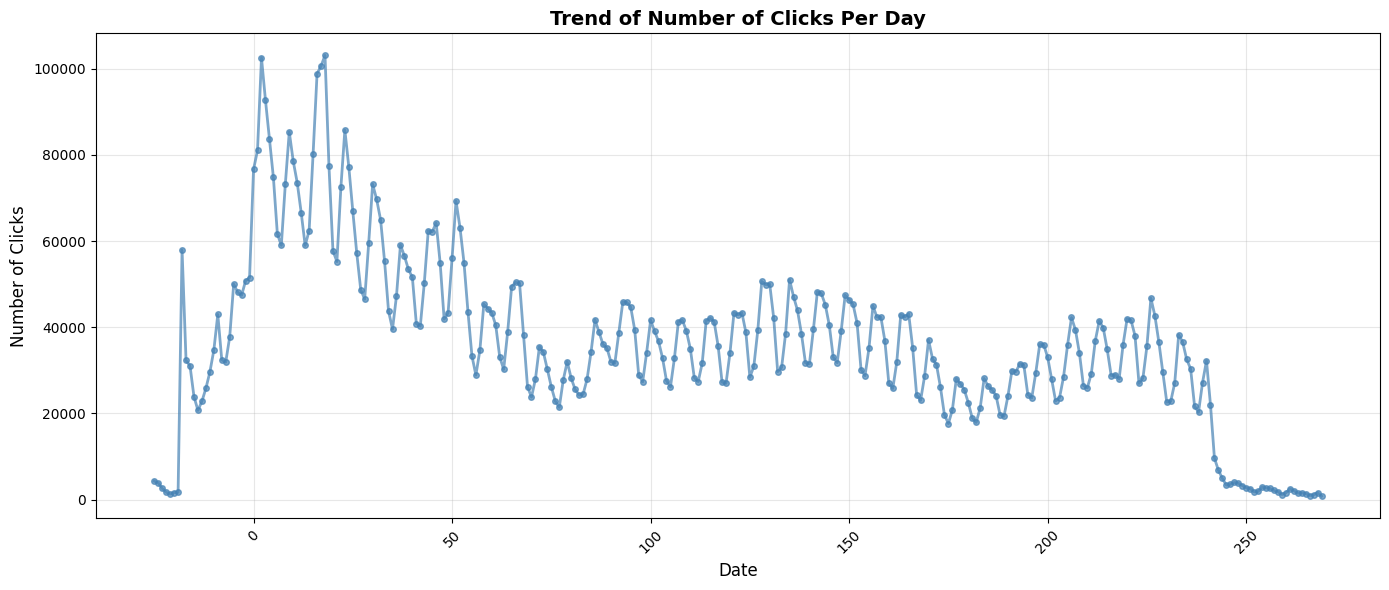

Daily Clicks Statistics:
count       295.00000
mean      36119.59322
std       19832.90666
min         814.00000
25%       26187.50000
50%       34627.00000
75%       44499.00000
max      103112.00000
dtype: float64

Date range: -25 to 269


In [10]:
# 10.1: Trend of number of clicks per day
daily_clicks = df.groupby('date').size().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_clicks.index, daily_clicks.values, color='steelblue', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax.set_title('Trend of Number of Clicks Per Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Clicks', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Daily Clicks Statistics:')
print(daily_clicks.describe())
print(f'\nDate range: {daily_clicks.index.min()} to {daily_clicks.index.max()}')